<a href="https://colab.research.google.com/github/jvit04/CursoIntroIA/blob/main/Actividad_Transferencia_de_Aprendizaje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Transferencia de Aprendizaje / Transfer Learning

In [ ]:
#Crear nuestro propio conjunto de datos

In [6]:
!
!apt-get install unrar # Install unrar
!unrar x piquero/piquero.rar # Extract the rar file

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from piquero/piquero.rar

Creating    PiqueroPatasAzules                                        OK
Extracting  PiqueroPatasAzules/image_1.jpg                                 0%  OK 
Extracting  PiqueroPatasAzules/image_10.jpg                                0%  OK 
Extracting  PiqueroPatasAzules/image_100.jpg                               1%  OK 
Extracting  PiqueroPatasAzules/image_101.jpg                               1%  OK 
Extracting  PiqueroPatasAzules/image_102.jpg                               1%  OK 
Extracting  PiqueroPatasAzules/image_103.jpg                               2%  OK 
Extracting  PiqueroPatasAzules/image_105.jp

In [7]:
!unrar x cuervo/cuervo.rar # Extract the rar file


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from cuervo/cuervo.rar

Extracting  cuervo/image_1.jpg                                             0%  OK 
Extracting  cuervo/image_10.jpg                                            0%  OK 
Extracting  cuervo/image_100.jpg                                           0%  OK 
Extracting  cuervo/image_101.jpg                                           0%  OK 
Extracting  cuervo/image_103.jpg                                           1%  OK 
Extracting  cuervo/image_104.jpg                                           1%  OK 
Extracting  cuervo/image_105.jpg                                           1%  OK 
Extracting  cuervo/image_106.jpg                                           2%  OK 
Extracting  cuervo/image_108.jpg                                           2%  OK 
Extracting  cuervo/image_109.jpg                             

In [9]:
#Crear un set de datos (ya no en memoria)
!mkdir -p dataset
!cp -r PiqueroPatasAzules dataset/piquero
!cp -r cuervo dataset/cuervo

In [10]:
from tensorflow import data
#Aumento de datos
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

#crear el dataset generador
datagen =  ImageDataGenerator(
rescale = 1.0/255,
rotation_range = 10,
width_shift_range = 0.15,
height_shift_range = 0.15,
shear_range = 5,
zoom_range = [0.7,1.3],
validation_split = 0.2
)

data_gen_train = datagen.flow_from_directory("/content/dataset",
                                             target_size = (224,224),
                                             batch_size = 32,
                                            shuffle=True,
                                             subset = "training")
data_gen_valid = datagen.flow_from_directory("/content/dataset",
                                             target_size = (224,224),
                                             batch_size = 32,
                                            shuffle=True,
                                             subset = "validation")

Found 538 images belonging to 2 classes.
Found 134 images belonging to 2 classes.


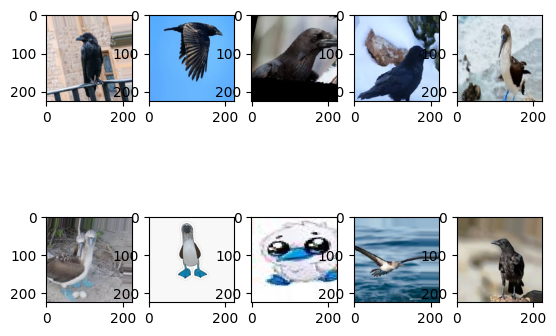

In [11]:
import matplotlib.pyplot as plt

for imagen,etiqueta in data_gen_train:
  for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(imagen[i])
  break
plt.show()

In [46]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

# Load MobileNetV2 feature extractor from Keras Applications
# include_top=False ensures we only get the convolutional base, not the classification head
# weights='imagenet' loads the pre-trained ImageNet weights
feature_extractor = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Freeze the feature extractor layers
feature_extractor.trainable = True

In [28]:
# The feature extractor is already frozen in the previous cell.

In [47]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = feature_extractor(inputs, training=False) # Use the feature_extractor
x = tf.keras.layers.GlobalAveragePooling2D()(x) # Add a GlobalAveragePooling layer for feature vector
outputs = tf.keras.layers.Dense(2, activation="softmax")(x)
modelo = tf.keras.Model(inputs=inputs, outputs=outputs)

In [48]:
modelo.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [49]:
EPOCAS = 20
train = modelo.fit(
    data_gen_train,
    epochs=EPOCAS,
    validation_data=data_gen_valid
)


Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 0.8662 - loss: 0.3261 - val_accuracy: 0.6493 - val_loss: 3.8089
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 534ms/step - accuracy: 0.9405 - loss: 0.1549 - val_accuracy: 0.7612 - val_loss: 1.7526
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 577ms/step - accuracy: 0.9628 - loss: 0.1298 - val_accuracy: 0.8060 - val_loss: 3.4965
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 470ms/step - accuracy: 0.9665 - loss: 0.0900 - val_accuracy: 0.7015 - val_loss: 6.1896
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 521ms/step - accuracy: 0.9758 - loss: 0.0830 - val_accuracy: 0.6493 - val_loss: 8.6334
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 533ms/step - accuracy: 0.9796 - loss: 0.0781 - val_accuracy: 0.7612 - val_loss: 3.5417
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 451ms/step - accuracy: 0.9610 - loss: 0.1372 - val_accuracy: 0.7537 - val_loss: 3.0960
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 529ms/step - accuracy: 0.9535 - loss: 0.1120 - val_accuracy: 0.7

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step


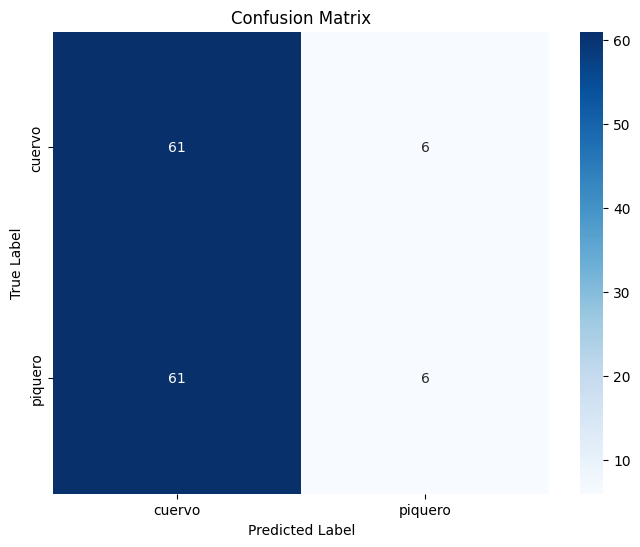

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get true labels
y_true = data_gen_valid.classes

# Get predictions
y_pred_probs = modelo.predict(data_gen_valid)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Get class names from the generator
class_names = list(data_gen_valid.class_indices.keys())

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [51]:
from PIL import Image
import cv2
import numpy as np

def categorizar(ruta):
  img=Image.open(ruta)
  img=img.convert("RGB")
  img=np.array(img).astype("float32")

  img = cv2.resize(img,(224,224))
  prediccion = modelo.predict(img.reshape(-1,224,224,3))
  return np.argmax(prediccion[0],axis=-1)

In [52]:
ruta = "piquero.jpg"
prediccion = categorizar(ruta)
print(prediccion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
0


In [53]:
ruta = "cuervo.jpg"
prediccion = categorizar(ruta)
print(prediccion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
0


In [54]:
print(data_gen_train.class_indices)

{'cuervo': 0, 'piquero': 1}
